In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install tensorflow-model-optimization
!pip install numba 

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, GlobalAveragePooling1D, Input, Add, ZeroPadding1D, BatchNormalization, LSTM, Bidirectional, TimeDistributed,Activation
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping
#from keras import optimizers
#from numba import cuda
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
#from tensorflow_model_optimization.python.core.keras.compat import keras
#from numba import cuda 
from tensorflow.keras.regularizers import l1, l2
%matplotlib inline

def get_model(n_features,  channels, n_outputs): #sequential model DNN 
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(n_features,  channels)),
        keras.layers.Conv1D(filters=64, kernel_size=5, activation='elu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Flatten(), #128, 64,32,16,16,8,8
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu', kernel_regularizer=l1(0.0026)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(n_outputs, activation='softmax'),
    ])

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) #categorical_crossentropy 72%

    return model

def get_data(train_file, test_file):


    train_df = pd.read_csv(train_file)
    X_train = train_df.drop('y', axis=1).values
    y_train = train_df.y.values
    X_train = X_train.reshape(X_train.shape[0],X_train.shape[1], 1)
    y_train = tf.keras.utils.to_categorical(y_train)
    test_df = pd.read_csv(test_file)
    X_test = test_df.drop('y', axis=1).values
    y_test = test_df.y.values
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    y_test = tf.keras.utils.to_categorical(y_test)


    return X_train, y_train, X_test, y_test


def get_acc(X_train, y_train, X_test, y_test, model, name):
    H = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1) # , callbacks=[early_stopping]
    y_pred = np.argmax(model.predict(X_test, batch_size=1), axis=1)

    print('classification report of CC400')
    y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
    report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
    print(report)
    conf_mat = confusion_matrix(y_classes, y_pred)
    sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    plt.savefig(f'/home/dmatthw/classes/EECS545/proj/{name}_confusion_matrix.png')

    fig, ax = plt.subplots(1,1)
    plt.plot(H.history["accuracy"])
    plt.plot(H.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.savefig(f'/home/dmatthw/classes/EECS545/proj/{name}_accuracy.png')

    fig, ax = plt.subplots(1,1)
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.savefig(f'/home/dmatthw/classes/EECS545/proj/{name}_loss.png')

2025-03-10 16:55:12.247584: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 16:55:12.248829: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 16:55:12.253470: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 16:55:12.265489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741640112.286111  653909 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741640112.29

# CC200

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


2025-03-10 16:55:33.121013: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/dmatthw/classes/EECS545/proj/env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2025-03-10 16:55:34.060322: W tensorflow/core/framework/dataset.cc:993] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


Epoch 1/50
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.3414 - loss: 2.2062

2025-03-10 16:55:56.513706: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]


62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 356ms/step - accuracy: 0.3440 - loss: 2.1947 - val_accuracy: 0.3964 - val_loss: 1.6520
Epoch 2/50


...

62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 389ms/step - accuracy: 0.9699 - loss: 0.1254 - val_accuracy: 0.7297 - val_loss: 2.8578
Epoch 47/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 372ms/step - accuracy: 0.9749 - loss: 0.1171 - val_accuracy: 0.7297 - val_loss: 2.8728
Epoch 48/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9687 - loss: 0.1209

2025-03-10 17:14:24.649224: W tensorflow/core/framework/dataset.cc:993] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 371ms/step - accuracy: 0.9687 - loss: 0.1209 - val_accuracy: 0.7387 - val_loss: 2.8526
Epoch 49/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.9699 - loss: 0.1169 - val_accuracy: 0.7297 - val_loss: 2.8057
Epoch 50/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9480 - loss: 0.1438

2025-03-10 17:15:11.135856: W tensorflow/core/framework/dataset.cc:993] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 370ms/step - accuracy: 0.9482 - loss: 0.1435 - val_accuracy: 0.7387 - val_loss: 2.8058
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
classification report of CC400
              precision    recall  f1-score   support

           1       0.66      0.70      0.68        44
           2       0.80      0.76      0.78        67

    accuracy                           0.74       111
   macro avg       0.73      0.73      0.73       111
weighted avg       0.74      0.74      0.74       111



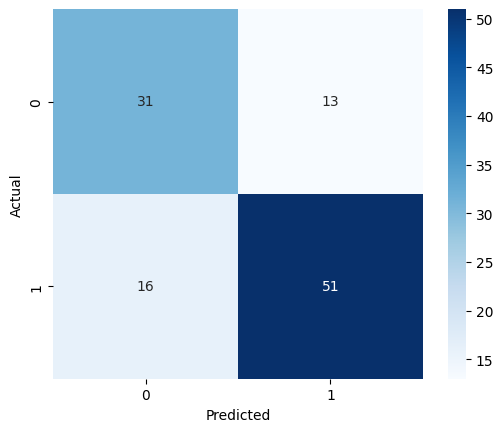

<Figure size 640x480 with 0 Axes>

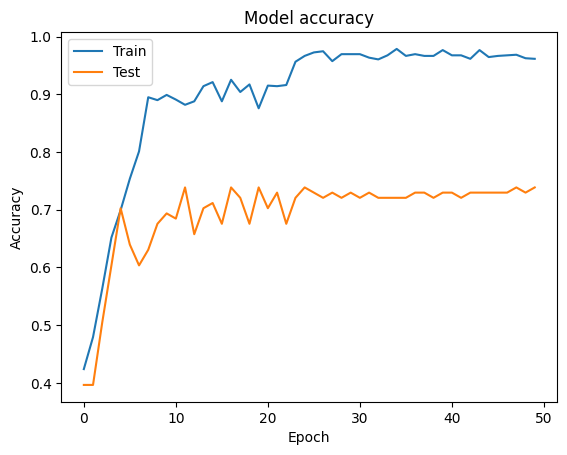

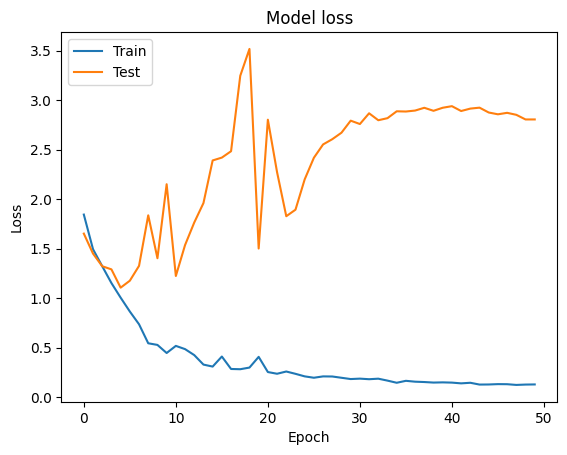

In [3]:
#Load data
#X_train, y_train, X_test, y_test = get_data('/kaggle/input/train-data/filt_noglobal/cc200_balanced_train_data.csv',
#         '/kaggle/input/train-data/filt_noglobal/cc200_balanced_test_data.csv')
X_train, y_train, X_test, y_test = get_data('/home/dmatthw/classes/EECS545/proj/datagen/traintest/train_data.csv',
         '/home/dmatthw/classes/EECS545/proj/datagen/traintest/test_data.csv')

strategy = tf.distribute.MirroredStrategy()
n_timesteps, n_features,  channels,  n_outputs = X_train.shape[0], X_train.shape[1], 1,  y_train.shape[1]

#Model init
with strategy.scope():
# model = get_model(76636, 1, 2)
    model = get_model(n_features,  channels, n_outputs)

#train
get_acc(X_train, y_train, X_test, y_test, model, 'CC200')

# print(model.summary())
# model.save('/kaggle/working/cc200_model.h5')

# #quantization part
# from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
# import tensorflow_model_optimization as tfmot

# quantize_model = tfmot.quantization.keras.quantize_model

# # q_aware stands for for quantization aware.
# q_aware_model = quantize_model(model)

# # `quantize_model` requires a recompile.
# q_aware_model.compile(optimizer='adam',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# print(q_aware_model.summary())


# H2 = q_aware_model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1) #Model Training

# y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of CC200 with quantization')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)

# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/cc200_lite_confusion_matrix.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history["accuracy"])
# plt.plot(H2.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/cc200_lite_accuracy.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history['loss'])
# plt.plot(H2.history['val_loss'])
# plt.title('Model loss')
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/cc200_lite_loss.png')
# q_aware_model.save('/kaggle/working/cc200_quantized_model.h5')


# #tflite part

# converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# quantized_tflite_model = converter.convert()

# interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
# interpreter.allocate_tensors()

# #testing tflite
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()
# y_pred = []
# for data in X_test:
#     input_data  = data.astype(np.float32).reshape(1, n_features,1)
#     interpreter.set_tensor(input_details[0]['index'], input_data)
#     interpreter.invoke()
#     output_data = interpreter.get_tensor(output_details[0]['index'])
#     y_pred.append(np.argmax(output_data))

# # y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of CC200 with tflite quentized')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)
# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/cc200_tflite_confusion_matrix.png')

# with open('/kaggle/working/cc200_quantized_tflite_model.tflite', 'wb') as f:
#     f.write(quantized_tflite_model)

# CC400

In [ ]:
#Load data
X_train, y_train, X_test, y_test = get_data('/kaggle/input/train-data/filt_noglobal/cc400_balanced_train_data.csv',
         '/kaggle/input/train-data/filt_noglobal/cc400_balanced_test_data.csv')

strategy = tf.distribute.MirroredStrategy()
n_timesteps, n_features,  channels,  n_outputs = X_train.shape[0], X_train.shape[1], 1,  y_train.shape[1]

#Model init
with strategy.scope():
# model = get_model(76636, 1, 2)
    model = get_model(n_features,  channels, n_outputs)

#train
get_acc(X_train, y_train, X_test, y_test, model, 'CC400')

# print(model.summary())
# model.save('/kaggle/working/cc400_model.h5')

# #quantization part
# from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
# import tensorflow_model_optimization as tfmot

# quantize_model = tfmot.quantization.keras.quantize_model

# # q_aware stands for for quantization aware.
# q_aware_model = quantize_model(model)

# # `quantize_model` requires a recompile.
# q_aware_model.compile(optimizer='adam',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# print(q_aware_model.summary())


# H2 = q_aware_model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1) #Model Training

# y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of CC400 with quantization')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)

# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/cc400_lite_confusion_matrix.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history["accuracy"])
# plt.plot(H2.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/cc400_lite_accuracy.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history['loss'])
# plt.plot(H2.history['val_loss'])
# plt.title('Model loss')
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/cc400_lite_loss.png')
# q_aware_model.save('/kaggle/working/cc400_quantized_model.h5')


# #tflite part

# converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# quantized_tflite_model = converter.convert()

# interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
# interpreter.allocate_tensors()

# #testing tflite
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()
# y_pred = []
# for data in X_test:
#     input_data  = data.astype(np.float32).reshape(1, n_features,1)
#     interpreter.set_tensor(input_details[0]['index'], input_data)
#     interpreter.invoke()
#     output_data = interpreter.get_tensor(output_details[0]['index'])
#     y_pred.append(np.argmax(output_data))

# # y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of CC400 with tflite quentized')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)
# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/cc400_tflite_confusion_matrix.png')

# with open('/kaggle/working/cc400_quantized_tflite_model.tflite', 'wb') as f:
#     f.write(quantized_tflite_model)

# AAL

In [ ]:
#Load data
X_train, y_train, X_test, y_test = get_data('/kaggle/input/train-data/filt_noglobal/aal_balanced_train_data.csv',
         '/kaggle/input/train-data/filt_noglobal/aal_balanced_test_data.csv')

strategy = tf.distribute.MirroredStrategy()
n_timesteps, n_features,  channels,  n_outputs = X_train.shape[0], X_train.shape[1], 1,  y_train.shape[1]

#Model init
with strategy.scope():
# model = get_model(76636, 1, 2)
    model = get_model(n_features,  channels, n_outputs)

#train
get_acc(X_train, y_train, X_test, y_test, model, 'AAL')

# print(model.summary())
# model.save('/kaggle/working/AAL_model.h5')

# #quantization part
# from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
# import tensorflow_model_optimization as tfmot

# quantize_model = tfmot.quantization.keras.quantize_model

# # q_aware stands for for quantization aware.
# q_aware_model = quantize_model(model)

# # `quantize_model` requires a recompile.
# q_aware_model.compile(optimizer='adam',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# print(q_aware_model.summary())


# H2 = q_aware_model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1) #Model Training

# y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of AAL with quantization')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)

# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/AAL_lite_confusion_matrix.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history["accuracy"])
# plt.plot(H2.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/AAL_lite_accuracy.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history['loss'])
# plt.plot(H2.history['val_loss'])
# plt.title('Model loss')
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/AAL_lite_loss.png')
# q_aware_model.save('/kaggle/working/AAL_quantized_model.h5')


# #tflite part

# converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# quantized_tflite_model = converter.convert()

# interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
# interpreter.allocate_tensors()

# #testing tflite
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()
# y_pred = []
# for data in X_test:
#     input_data  = data.astype(np.float32).reshape(1, n_features,1)
#     interpreter.set_tensor(input_details[0]['index'], input_data)
#     interpreter.invoke()
#     output_data = interpreter.get_tensor(output_details[0]['index'])
#     y_pred.append(np.argmax(output_data))

# # y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of AAL with tflite quentized')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)
# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/AAL_tflite_confusion_matrix.png')

# with open('/kaggle/working/AAL_quantized_tflite_model.tflite', 'wb') as f:
#     f.write(quantized_tflite_model)

# Dosen

In [ ]:
#Load data
X_train, y_train, X_test, y_test = get_data('/kaggle/input/train-data/filt_noglobal/dosen_balanced_train_data.csv',
         '/kaggle/input/train-data/filt_noglobal/dosen_balanced_test_data.csv')

strategy = tf.distribute.MirroredStrategy()
n_timesteps, n_features,  channels,  n_outputs = X_train.shape[0], X_train.shape[1], 1,  y_train.shape[1]

#Model init
with strategy.scope():
# model = get_model(76636, 1, 2)
    model = get_model(n_features,  channels, n_outputs)

#train
get_acc(X_train, y_train, X_test, y_test, model, 'Dosen')

# print(model.summary())
# model.save('/kaggle/working/dosen_model.h5')

# #quantization part
# from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
# import tensorflow_model_optimization as tfmot

# quantize_model = tfmot.quantization.keras.quantize_model

# # q_aware stands for for quantization aware.
# q_aware_model = quantize_model(model)

# # `quantize_model` requires a recompile.
# q_aware_model.compile(optimizer='adam',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# print(q_aware_model.summary())


# H2 = q_aware_model.fit( X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1) #Model Training

# y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of dosen with quantization')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)

# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/dosen_lite_confusion_matrix.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history["accuracy"])
# plt.plot(H2.history['val_accuracy'])
# plt.title('Model accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/dosen_lite_accuracy.png')

# fig, ax = plt.subplots(1,1)
# plt.plot(H2.history['loss'])
# plt.plot(H2.history['val_loss'])
# plt.title('Model loss')
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.legend(['Train', 'Test'], loc='upper left')
# plt.show()
# plt.savefig(f'/kaggle/working/dosen_lite_loss.png')
# q_aware_model.save('/kaggle/working/dosen_quantized_model.h5')


# #tflite part

# converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# quantized_tflite_model = converter.convert()

# interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
# interpreter.allocate_tensors()

# #testing tflite
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()
# y_pred = []
# for data in X_test:
#     input_data  = data.astype(np.float32).reshape(1, n_features,1)
#     interpreter.set_tensor(input_details[0]['index'], input_data)
#     interpreter.invoke()
#     output_data = interpreter.get_tensor(output_details[0]['index'])
#     y_pred.append(np.argmax(output_data))

# # y_pred = np.argmax(q_aware_model.predict(X_test, batch_size=1), axis=1)
# print('classification report of dosen with tflite quentized')
# y_classes = [np.argmax(y, axis=None, out=None) for y in y_test]
# report = classification_report(y_classes, y_pred, zero_division=0) #, target_names=['ASD', 'TC']
# print(report)
# conf_mat = confusion_matrix(y_classes, y_pred)
# sns.heatmap(conf_mat, square=True, annot=True, cmap='Blues', fmt='d', cbar=True)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# plt.savefig(f'/kaggle/working/dosen_tflite_confusion_matrix.png')

# with open('/kaggle/working/dosen_quantized_tflite_model.tflite', 'wb') as f:
#     f.write(quantized_tflite_model)